# 02 - Acquisition geometry in 3D

Notebook 01 established what is in the product. This one answers a different question: where was
the satellite, where was it pointing, and does that agree with what the metadata claims?

A radar satellite never looks straight down. It looks off to one side, because a radar measures
distance, and pointing straight down would put two targets - one left, one right - at the same
distance with no way to tell them apart. Looking sideways breaks that ambiguity.

That single fact drives the whole geometry: the satellite passes hundreds of kilometres away
from the thing it is imaging. In notebook 01 that showed up as a scene centre sitting well off
the ground track. Here we reconstruct it properly and draw it.

**The plan**

1. Reload the orbit and the acquisition metadata
2. Set up the coordinate frames we need
3. Interpolate the satellite position to the exact moment of acquisition
4. Compute the viewing angles from first principles and check them against the delivered values
5. Draw it in 3D

Step 4 is the real test. If numbers we derive from the orbit match numbers Synspective wrote in
the metadata, we have understood the geometry rather than guessed at it.

This notebook stands alone - run it without running 01 first.

## Setup

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely import wkt as shapely_wkt

# Locate the repository root by walking up from wherever the kernel started.
# VS Code runs notebooks from the workspace folder, Jupyter from the notebook folder -
# this works either way, so the paths below do not depend on editor settings.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'data').is_dir())
SCENE = ROOT / 'data' / 'StriX-3_20260615_063527_SL1_202606-00876'
PAR      = SCENE / 'GRD_Geotiff' / 'PAR-VV-STRIX3-20260615T063527Z-SLGRD.xml'
ORT_META = SCENE / 'ORT_Geotiff' / 'IMG-VV-STRIX3-20260615T063527Z-SLORT-gamma0-metadata.xml'

tag = lambda el: el.tag.rsplit('}', 1)[-1]

for p in (PAR, ORT_META):
    print('OK  ' if p.exists() else 'MISS', p.name)

OK   PAR-VV-STRIX3-20260615T063527Z-SLGRD.xml
OK   IMG-VV-STRIX3-20260615T063527Z-SLORT-gamma0-metadata.xml


## 1. Load the orbit and the metadata

Two things come out of the delivered files.

The **state vectors** are the satellite's measured orbit: 28 samples, 22 seconds apart, each one
a timestamp plus a position and a velocity. They are given in **ECEF** coordinates - metres from
the centre of the Earth, on axes that rotate with the planet.

The **acquisition metadata** tells us what the radar was doing: which way it pointed, at what
angle, and where the resulting image landed. Those are the values we are going to try to
reproduce.

In [2]:
# state vectors
cols = ['posX', 'posY', 'posZ', 'velX', 'velY', 'velZ']
sv = [{tag(k): (k.text or '').strip() for k in el}
      for el in ET.parse(PAR).getroot().iter() if tag(el) == 'stateVec']

orbit = pd.DataFrame(sv)
orbit['timeUTC'] = pd.to_datetime(orbit['timeUTC'])
orbit[cols] = orbit[cols].astype(float)

# flat name -> value lookup over the CEOS-ARD metadata
m = {tag(el): el.text.strip()
     for el in ET.parse(ORT_META).getroot().iter()
     if len(el) == 0 and (el.text or '').strip()}

print(f'{len(orbit)} state vectors from {orbit.timeUTC.iloc[0]} to {orbit.timeUTC.iloc[-1]}')
print(f'{len(m)} metadata fields')
print()
for k in ['ObservationMode', 'AntennaPointing', 'PassDirection', 'PlatformHeading',
          'IncAngleNearRange', 'IncAngleFarRange', 'CenterLatitude', 'CenterLongitude']:
    print(f'  {k:20} {m[k]}')

28 state vectors from 2026-06-15 06:30:27.606518 to 2026-06-15 06:40:27.606512
85 metadata fields

  ObservationMode      Sliding Spotlight
  AntennaPointing      Left
  PassDirection        Ascending
  PlatformHeading      347.74
  IncAngleNearRange    34.34
  IncAngleFarRange     35.25
  CenterLatitude       32.887635
  CenterLongitude      131.092252


## 2. Coordinate frames

Three ways of describing the same point, each convenient for something different.

**Geodetic** - latitude, longitude, height. What humans read, and what goes on a map.

**ECEF** (Earth-Centred, Earth-Fixed) - X, Y, Z in metres from the centre of the Earth, axes
turning with the planet. What the orbit file uses. Good for geometry, because distances and
angles between points are just vector arithmetic.

**ENU** (East, North, Up) - a local frame pinned to one point on the ground. X points east,
Y north, Z straight up. This is the frame that makes the picture readable: in ENU, "the
satellite was 355 km to the west and 505 km up" is literally the coordinates.

All three assume the **WGS84 ellipsoid**, the standard flattened-sphere model of the Earth - it
is about 21 km wider across the equator than pole to pole, and ignoring that would put us
kilometres off.

In [3]:
A_WGS84 = 6378137.0                 # equatorial radius, metres
F_WGS84 = 1 / 298.257223563         # flattening
E2 = F_WGS84 * (2 - F_WGS84)        # eccentricity squared


def geodetic_to_ecef(lat_deg, lon_deg, h=0.0):
    """(lat, lon, height) -> ECEF XYZ metres."""
    lat, lon = np.radians(lat_deg), np.radians(lon_deg)
    N = A_WGS84 / np.sqrt(1 - E2 * np.sin(lat) ** 2)
    return np.stack([(N + h) * np.cos(lat) * np.cos(lon),
                     (N + h) * np.cos(lat) * np.sin(lon),
                     (N * (1 - E2) + h) * np.sin(lat)], axis=-1)


def ecef_to_geodetic(x, y, z):
    """ECEF XYZ metres -> (lat deg, lon deg, height m). Iterative: no exact closed form."""
    lon = np.degrees(np.arctan2(y, x))
    p = np.hypot(x, y)
    lat = np.arctan2(z, p * (1 - E2))
    for _ in range(6):
        N = A_WGS84 / np.sqrt(1 - E2 * np.sin(lat) ** 2)
        h = p / np.cos(lat) - N
        lat = np.arctan2(z, p * (1 - E2 * N / (N + h)))
    N = A_WGS84 / np.sqrt(1 - E2 * np.sin(lat) ** 2)
    return np.degrees(lat), lon, p / np.cos(lat) - N


def enu_basis(lat_deg, lon_deg):
    """Unit East, North, Up vectors (in ECEF) at a point on the ellipsoid."""
    lat, lon = np.radians(lat_deg), np.radians(lon_deg)
    east  = np.array([-np.sin(lon), np.cos(lon), 0.0])
    north = np.array([-np.sin(lat) * np.cos(lon), -np.sin(lat) * np.sin(lon), np.cos(lat)])
    up    = np.array([ np.cos(lat) * np.cos(lon),  np.cos(lat) * np.sin(lon), np.sin(lat)])
    return east, north, up


def ecef_to_enu(p_ecef, lat0, lon0, h0=0.0):
    """ECEF points -> local East/North/Up metres, relative to a reference point."""
    east, north, up = enu_basis(lat0, lon0)
    d = np.atleast_2d(p_ecef) - geodetic_to_ecef(lat0, lon0, h0)
    return np.squeeze(d @ np.stack([east, north, up], axis=1))

## 3. Where was the satellite at the exact moment?

The acquisition lasted 1.41 seconds and finished between two state vectors, so we have to
interpolate.

Straight-line interpolation between the two nearest samples would be wrong here. An orbit is
curved, and over a 22-second gap a straight line cuts the corner by tens of metres. The standard
fix in flight dynamics is **Lagrange interpolation**: fit a single polynomial through the
nearest several samples and evaluate it. Eight points is the usual choice - enough to follow the
curve, few enough to stay numerically well behaved.

In [4]:
def lagrange_interp(t_nodes, values, t, order=8):
    """Lagrange interpolation of vector `values` sampled at `t_nodes`, evaluated at `t`."""
    i = np.argsort(np.abs(t_nodes - t))[:order]     # the `order` nearest samples
    tn, vn = t_nodes[i], values[i]
    out = np.zeros(vn.shape[1])
    for k in range(len(tn)):
        w = np.prod([(t - tn[j]) / (tn[k] - tn[j]) for j in range(len(tn)) if j != k])
        out += w * vn[k]
    return out


# the acquisition midpoint, from the CEOS-ARD metadata
t_start = pd.Timestamp(m['FirstAcquisitionDate']).tz_localize(None)
t_end   = pd.Timestamp(m['LastAcquisitionDate']).tz_localize(None)
t_acq   = t_start + (t_end - t_start) / 2

t0   = orbit.timeUTC.iloc[0]
tsec = (orbit.timeUTC - t0).dt.total_seconds().values
t_at = (t_acq - t0).total_seconds()

sat_pos = lagrange_interp(tsec, orbit[cols[:3]].values, t_at)
sat_vel = lagrange_interp(tsec, orbit[cols[3:]].values, t_at)

sat_lat, sat_lon, sat_h = ecef_to_geodetic(*sat_pos)

print(f'acquisition   {t_start.time()} to {t_end.time()}  ({(t_end-t_start).total_seconds():.2f} s)')
print(f'midpoint      {t_acq}')
print(f'subsatellite  {sat_lat:.4f} N, {sat_lon:.4f} E')
print(f'altitude      {sat_h/1e3:.2f} km')
print(f'speed         {np.linalg.norm(sat_vel)/1e3:.3f} km/s')

acquisition   06:35:26.687942 to 06:35:28.096020  (1.41 s)
midpoint      2026-06-15 06:35:27.391981
subsatellite  33.5369 N, 134.4059 E
altitude      504.07 km
speed         7.698 km/s


## 4. Derive the viewing angles, and check them

Now the test. From the satellite position and the scene centre alone, we compute the geometry
and compare it to what Synspective delivered.

Two angles that sound the same and are not:

- **Off-nadir angle** - measured *at the satellite*, between straight down and the direction it
  is pointing. This is the number an operator plans with, because it is what the spacecraft has
  to physically achieve.
- **Incidence angle** - measured *at the ground*, between straight up and the direction back to
  the satellite. This is what controls how bright the image is.

On a flat Earth they would be equal. They are not equal, because the Earth curves away beneath
the beam, and the size of the difference is a direct measure of that curvature.

We also check which side the radar looked at. Taking the cross product of "up" with the
direction of travel gives the vector pointing to the satellite's left, so the sign of the dot
product with the look direction settles left versus right.

In [5]:
scene_lat, scene_lon = float(m['CenterLatitude']), float(m['CenterLongitude'])
target = geodetic_to_ecef(scene_lat, scene_lon, 0.0)

look = target - sat_pos                       # satellite -> ground
slant_range = np.linalg.norm(look)
look_hat = look / slant_range

_, _, up_sat = enu_basis(sat_lat, sat_lon)          # straight up at the satellite
e_t, n_t, up_t = enu_basis(scene_lat, scene_lon)    # frame at the target

ang = lambda u, v: np.degrees(np.arccos(np.clip(np.dot(u, v), -1, 1)))

off_nadir = ang(look_hat, -up_sat)            # at the satellite, from straight down
incidence = ang(-look_hat, up_t)              # at the target, from straight up

# which side did it look at? up x velocity points to the satellite's left
vel_hat = sat_vel / np.linalg.norm(sat_vel)
left_hat = np.cross(up_sat, vel_hat)
side = 'Left' if np.dot(look_hat, left_hat) > 0 else 'Right'

# heading over the ground, from the ECEF velocity
v_enu = sat_vel @ np.stack(enu_basis(sat_lat, sat_lon), axis=1)
heading = np.degrees(np.arctan2(v_enu[0], v_enu[1])) % 360

# how far away on the ground
nadir = geodetic_to_ecef(sat_lat, sat_lon, 0.0)
ground_range = A_WGS84 * ang(nadir / np.linalg.norm(nadir),
                             target / np.linalg.norm(target)) * np.pi / 180

check = pd.DataFrame([
    ('off-nadir angle',  f'{off_nadir:.2f} deg',      m['offnadirAngle'] if 'offnadirAngle' in m else '31.94'),
    ('incidence angle',  f'{incidence:.2f} deg',      f"{m['IncAngleNearRange']} - {m['IncAngleFarRange']}"),
    ('look side',        side,                        m['AntennaPointing']),
    ('pass direction',   'Ascending' if v_enu[1] > 0 else 'Descending', m['PassDirection']),
    ('platform heading', f'{heading:.2f} deg',        m['PlatformHeading']),
    ('slant range',      f'{slant_range/1e3:.1f} km', '-'),
    ('ground range',     f'{ground_range/1e3:.1f} km', '-'),
], columns=['quantity', 'derived here', 'delivered metadata'])

check.set_index('quantity')

,derived here,delivered metadata
quantity,,
off-nadir angle,31.77 deg,31.94
incidence angle,34.62 deg,34.34 - 35.25
look side,Left,Left
pass direction,Ascending,Ascending
platform heading,347.74 deg,347.74
slant range,602.2 km,-
ground range,317.5 km,-


### What the comparison says

The heading matches the delivered value exactly, and the look side and pass direction both come
out right. Those are the checks that would fail loudly if any frame or sign convention were
wrong, so agreeing to two decimal places is worth more than it looks.

The two angles land within about 0.2 degrees. That is close, but it is not zero, and the
difference is worth accounting for rather than waving through. One assumption we made is
visible: we placed the target at sea level, and this scene is a volcano. The cell below shows
how much that assumption is worth.

In [6]:
rows = []
for h_t in (0, 500, 1000, 1592):        # 1592 m is the summit of Mt. Aso
    lk = geodetic_to_ecef(scene_lat, scene_lon, h_t) - sat_pos
    rows.append((h_t, ang(lk / np.linalg.norm(lk), -up_sat)))

sens = pd.DataFrame(rows, columns=['assumed target height (m)', 'off-nadir angle (deg)'])
sens['difference from delivered'] = sens['off-nadir angle (deg)'] - 31.94
sens.round(3).set_index('assumed target height (m)')

,off-nadir angle (deg),difference from delivered
assumed target height (m),,
0,31.771,-0.169
500,31.798,-0.142
1000,31.825,-0.115
1592,31.857,-0.083


Terrain height moves the angle in the right direction but only accounts for a fraction of the
gap - roughly 0.05 degrees per kilometre of elevation. So the sea-level assumption is part of
the story and not all of it.

The rest is most likely a definition difference. We measured to the centre of the orthorectified
product, which is the middle of the image after it was warped onto a map grid. The delivered
off-nadir angle refers to where the beam was actually aimed, and those two points are close but
not identical.

That distinction is the useful takeaway. Getting to within 0.2 degrees from the orbit file alone
confirms the frames, the interpolation and the angle conventions are right. Closing the last
0.2 degrees would mean knowing exactly which point on the ground each delivered number refers
to - which is a question for the Format Manual, not for more arithmetic.

## 5. The 3D view

Two panels, because the geometry spans two very different scales.

**Left - global.** The Earth, the ten-minute arc of orbit, and the line of sight down to the
target. This is the panel that shows how close in the satellite actually is: 505 km of altitude
against a 6378 km radius, so the orbit hugs the surface.

**Right - local.** The same moment in the East/North/Up frame centred on the scene, which is
where the side-looking geometry becomes obvious. The satellite sits high and far to one side,
the dashed line drops to the point directly beneath it, and the solid line is where the radar
was actually pointing. The angle between them is the off-nadir angle.

The scene footprint is drawn on the ground plane. It is about 13 km across against a plot
several hundred kilometres wide, so it reads as a small patch - which is itself the point, and
the reason a planning tool needs a map rather than a list of numbers.

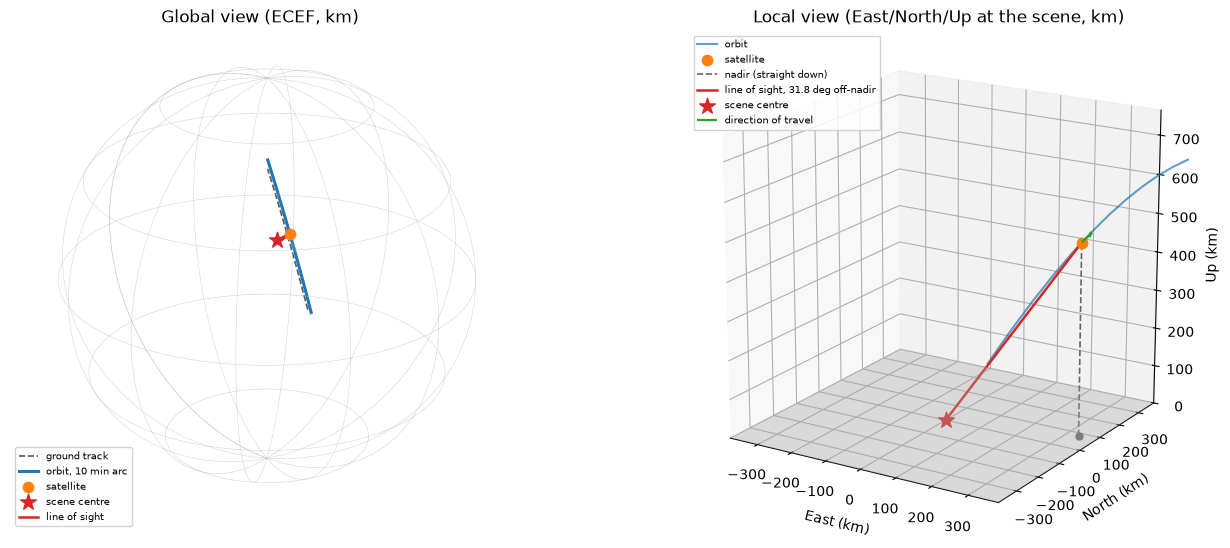

In [7]:
footprint = shapely_wkt.loads(m['ProductGeographicalExtent'])
fp_lon, fp_lat = np.array(footprint.exterior.xy)
fp_ecef = geodetic_to_ecef(fp_lat, fp_lon, 0.0)

fig = plt.figure(figsize=(14, 6.5))

# ---------------------------------------------------------------- global, ECEF
ax = fig.add_subplot(1, 2, 1, projection='3d')

# graticule every 30 deg. A wireframe rather than a solid surface: matplotlib does not
# depth-sort lines against surfaces, so a filled globe would hide the orbit behind it.
u, v = np.linspace(0, 2 * np.pi, 73), np.linspace(0, np.pi, 37)
b_km = A_WGS84 * (1 - F_WGS84) / 1e3
ax.plot_wireframe(A_WGS84 / 1e3 * np.outer(np.cos(u), np.sin(v)),
                  A_WGS84 / 1e3 * np.outer(np.sin(u), np.sin(v)),
                  b_km * np.outer(np.ones_like(u), np.cos(v)),
                  rstride=6, cstride=6, color='0.75', lw=.4, alpha=.65)

track = orbit[cols[:3]].values / 1e3
sub_lat, sub_lon, _ = ecef_to_geodetic(*orbit[cols[:3]].values.T)
subtrack = geodetic_to_ecef(sub_lat, sub_lon, 0.0) / 1e3

ax.plot(*subtrack.T, color='0.35', lw=1.2, ls='--', label='ground track')
ax.plot(*track.T, color='tab:blue', lw=2.2, label='orbit, 10 min arc')
ax.scatter(*sat_pos / 1e3, color='tab:orange', s=55, depthshade=False, label='satellite')
ax.scatter(*target / 1e3, color='tab:red', marker='*', s=140, depthshade=False,
           label='scene centre')
ax.plot(*np.stack([sat_pos, target]).T / 1e3, color='tab:red', lw=1.8, label='line of sight')

R = 6600
ax.set(xlim=(-R, R), ylim=(-R, R), zlim=(-R, R))
ax.set_box_aspect([1, 1, 1], zoom=1.45)
ax.view_init(elev=24, azim=128)
ax.set_title('Global view (ECEF, km)')
ax.legend(fontsize=7, loc='lower left', framealpha=.85)
ax.set_axis_off()

# ---------------------------------------------------------------- local, ENU
ax = fig.add_subplot(1, 2, 2, projection='3d')
sat_enu = ecef_to_enu(sat_pos, scene_lat, scene_lon) / 1e3
fp_enu  = ecef_to_enu(fp_ecef, scene_lat, scene_lon) / 1e3
trk_enu = ecef_to_enu(orbit[cols[:3]].values, scene_lat, scene_lon) / 1e3

span = max(abs(sat_enu[0]), abs(sat_enu[1])) * 1.15
gx, gy = np.meshgrid(np.linspace(-span, span, 2), np.linspace(-span, span, 2))
ax.plot_surface(gx, gy, np.zeros_like(gx), color='0.85', alpha=.35, linewidth=0, zorder=0)

keep = np.abs(trk_enu[:, 0]) < span * 1.4
ax.plot(*trk_enu[keep].T, color='tab:blue', lw=1.5, alpha=.7, label='orbit')
ax.scatter(*sat_enu, color='tab:orange', s=55, depthshade=False, label='satellite')
ax.plot([sat_enu[0], sat_enu[0]], [sat_enu[1], sat_enu[1]], [0, sat_enu[2]],
        color='0.4', ls='--', lw=1.2, label='nadir (straight down)')
ax.scatter(sat_enu[0], sat_enu[1], 0, color='0.4', s=25, depthshade=False)
ax.plot([sat_enu[0], 0], [sat_enu[1], 0], [sat_enu[2], 0],
        color='tab:red', lw=1.8, label=f'line of sight, {off_nadir:.1f} deg off-nadir')
ax.plot(fp_enu[:, 0], fp_enu[:, 1], fp_enu[:, 2], color='tab:red', lw=2)
ax.scatter(0, 0, 0, color='tab:red', marker='*', s=140, depthshade=False, label='scene centre')

ax.quiver(*sat_enu, *(v_enu / np.linalg.norm(v_enu) * span * .22),
          color='tab:green', lw=1.6, arrow_length_ratio=.25, label='direction of travel')

ax.set(xlim=(-span, span), ylim=(-span, span), zlim=(0, 2 * span),
       xlabel='East (km)', ylabel='North (km)', zlabel='Up (km)')
ax.set_box_aspect([1, 1, 1], zoom=1.05)
ax.view_init(elev=18, azim=-58)
ax.set_title('Local view (East/North/Up at the scene, km)')
ax.legend(fontsize=7, loc='upper left', framealpha=.85)

fig.subplots_adjust(wspace=.02, left=.02, right=.98)

### Reading the figure

On the left, the orbit arc sits just above the surface. Ten minutes of flight covers a visibly
small part of the globe, and the line of sight down to the target is short enough to be almost
lost against the Earth's radius - a reminder that "space" here is 500 km, not an astronomical
distance.

On the right, the actual working geometry. The satellite is up and well off to one side, the
dashed line marks where straight down would land, and the red line is where the radar was
pointing. The gap between those two lines at ground level is the 317 km of ground range in the
table above. The green arrow is the direction of travel: the line of sight goes off to its left,
which is what `AntennaPointing: Left` meant.

The footprint is the small red quadrilateral at the base of the line of sight. It is roughly
13 km across on a plot 700 km wide, which is a fair picture of the planning problem - a narrow,
steerable beam that has to be aimed precisely, on a satellite that is only over any given target
for a couple of minutes.